# DANN — adaptation de domaine pour la portabilité (Colab GPU)

Notebook **autonome** dédié à l'entraînement du DANN sur `AES_PT_light.h5`.
Il ne dépend ni du notebook consolidé ni de `sca_utils.py`.

**Avant de lancer :**
1. `Exécution > Modifier le type d'exécution > GPU (T4)`.
2. Mets `AES_PT_light.h5` sur ton Drive dans `MyDrive/dl-sca/`.

**Comment l'utiliser :** lance tout une première fois en mode rapide (`QUICK=True`)
pour vérifier que le DANN *descend*. Si oui, passe `QUICK=False` pour les vrais
chiffres. Pour D3/D4, change `TGT_DEV` et relance les cellules de données → fin.

## 0. GPU, Drive et chemins

In [31]:
import os, numpy as np, tensorflow as tf
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/crypto'
AES_PT_PATH = os.path.join(DATA_DIR, 'AES_PT_light.h5')   # <- ton fichier réduit
FIG_DIR = os.path.join(DATA_DIR, 'figures'); os.makedirs(FIG_DIR, exist_ok=True)

gpus = tf.config.list_physical_devices('GPU')
print('GPU    :', bool(gpus), '|', gpus if gpus else '(AUCUN — active le GPU T4 !)')
print('Fichier:', AES_PT_PATH, '|', 'présent' if os.path.exists(AES_PT_PATH) else 'ABSENT')
SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU    : True | [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Fichier: /content/drive/MyDrive/crypto/AES_PT_light.h5 | présent


## 1. Boîte à outils (S-box, guessing entropy)

In [32]:
AES_SBOX = np.array([
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16,
], dtype=np.uint8)

def guessing_entropy(preds, pt, true_key, n_attack=1000, n_exp=50, seed=0):
    rng = np.random.default_rng(seed); lp = np.log(preds + 1e-40); N = preds.shape[0]
    n_attack = min(n_attack, N); kh = np.arange(256, dtype=np.uint8); ge = np.zeros(n_attack)
    for _ in range(n_exp):
        idx = rng.permutation(N)[:n_attack]; s = np.zeros(256)
        for st, i in enumerate(idx):
            s += lp[i, AES_SBOX[pt[i] ^ kh]]; ge[st] += np.count_nonzero(s > s[true_key])
    return ge / n_exp

def traces_to_break(ge, thresh=0.5):
    hit = np.where(ge < thresh)[0]
    return int(hit[0] + 1) if len(hit) else None

## 2. Chargeur AES_PT

In [33]:
import h5py
def load_aes_pt(path, device='D1', impl='Unprotected', keytype='RndmKey', byte=0, n=None):
    base = f'{device}/{impl}/{keytype}'
    with h5py.File(path, 'r') as f:
        tr = f[f'{base}/Traces']
        N = tr.shape[0] if n is None else min(int(n), tr.shape[0])
        traces = np.asarray(tr[:N], dtype=np.float32)
        pt  = np.asarray(f[f'{base}/Data/Plaintext'][:N, byte], dtype=np.uint8)
        key = np.asarray(f[f'{base}/Data/Key'][:N, byte], dtype=np.uint8)
    return {'traces': traces, 'labels': AES_SBOX[pt ^ key].astype(np.int64), 'pt': pt, 'key': key}

## 3. Modèles (MLP source-seul, DANN avec couche d'inversion de gradient)

In [34]:
from tensorflow.keras import layers, models, optimizers

def make_mlp(n_samples, lr=1e-3):
    m = models.Sequential([layers.Input((n_samples,))] +
        [layers.Dense(200, activation='relu') for _ in range(4)] +
        [layers.Dense(256, activation='softmax')])
    m.compile(optimizer=optimizers.Adam(lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

class GradReverse(layers.Layer):
    def __init__(self, **kw):
        super().__init__(**kw)
        self.lamb = self.add_weight(name='lamb', shape=(), initializer='zeros', trainable=False)
    def call(self, x):
        lam = self.lamb
        @tf.custom_gradient
        def f(z):
            return tf.identity(z), lambda dy: -lam * dy
        return f(x)

def build_dann(n_samples):
    inp = layers.Input((n_samples,))
    x = layers.Dense(200, activation='relu')(inp)
    x = layers.Dense(200, activation='relu')(x)
    feat = layers.Dense(200, activation='relu')(x)
    c = layers.Dense(200, activation='relu')(feat)
    class_out = layers.Dense(256, activation='softmax', name='class')(c)
    grl = GradReverse(name='grl'); d = grl(feat)
    d = layers.Dense(100, activation='relu')(d)
    domain_out = layers.Dense(2, activation='softmax', name='domain')(d)
    m = models.Model(inp, {'class': class_out, 'domain': domain_out})
    m.compile(optimizer=optimizers.Adam(1e-3),
        loss={'class': 'sparse_categorical_crossentropy', 'domain': 'sparse_categorical_crossentropy'},
        loss_weights={'class': 1.0, 'domain': 1.0},
        metrics={'class': 'accuracy', 'domain': 'accuracy'})
    return m, grl

class LambdaSchedule(tf.keras.callbacks.Callback):
    # lambda = 0 pendant le warmup, puis montée sigmoïde jusqu'à max_lambda
    def __init__(self, grl, total, warmup=20, gamma=10.0, max_lambda=0.5):
        self.grl=grl; self.total=total; self.warmup=warmup; self.gamma=gamma; self.maxl=max_lambda
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup: lam = 0.0
        else:
            p = (epoch - self.warmup) / max(1, self.total - self.warmup - 1)
            lam = (2.0/(1.0+np.exp(-self.gamma*p)) - 1.0) * self.maxl
        self.grl.lamb.assign(np.float32(lam))

## 4. Configuration

In [52]:
QUICK = False          # True = essai rapide (vérifier que ça descend) ; False = vrais chiffres
SRC_DEV, TGT_DEV = 'D1', 'D2'  # source (profilage) -> cible (attaque). Change TGT pour D3, D4.
TARGET_BYTE = 0

if QUICK:
    N_TRAIN, EPOCHS, WARMUP, N_EXP = 15000, 30, 10, 20
else:
    N_TRAIN, EPOCHS, WARMUP, N_EXP = 40000, 60, 30, 50
MAX_LAMBDA = 0.1
# Accumulateur de résultats (conservé entre les exécutions de différentes cibles)
RESULTS = globals().get('RESULTS', {})
print(f'{SRC_DEV} -> {TGT_DEV} | byte {TARGET_BYTE} | N_TRAIN={N_TRAIN} EPOCHS={EPOCHS} | QUICK={QUICK}')

D1 -> D2 | byte 0 | N_TRAIN=40000 EPOCHS=60 | QUICK=False


## 5. Préparation des données (source + cible)

In [53]:
from sklearn.preprocessing import StandardScaler

src = load_aes_pt(AES_PT_PATH, SRC_DEV, 'Unprotected', 'RndmKey', byte=TARGET_BYTE, n=N_TRAIN)
tgt = load_aes_pt(AES_PT_PATH, TGT_DEV, 'Unprotected', 'RndmKey', byte=TARGET_BYTE, n=N_TRAIN)

scaler_src = StandardScaler().fit(src['traces'])
scaler_tgt = StandardScaler().fit(tgt['traces'])
Xs = scaler_src.transform(src['traces']).astype(np.float32)
Xt = scaler_tgt.transform(tgt['traces']).astype(np.float32)
ns, nt = len(Xs), len(Xt)
n_samples = Xs.shape[1]

# Empilage pour le DANN : classe connue côté source seulement (poids 0 côté cible),
# domaine = 0 (source) / 1 (cible).
X        = np.concatenate([Xs, Xt]).astype(np.float32)
y_class  = np.concatenate([src['labels'], np.zeros(nt)]).astype(np.int64)
y_domain = np.concatenate([np.zeros(ns), np.ones(nt)]).astype(np.int64)
w_class  = np.concatenate([np.ones(ns), np.zeros(nt)]).astype(np.float32)
w_domain = np.ones(ns + nt, np.float32)

# Jeu d'attaque : clé fixe de la cible
atk = load_aes_pt(AES_PT_PATH, TGT_DEV, 'Unprotected', 'FixedKey', byte=TARGET_BYTE, n=50000)
tk_tgt = int(np.bincount(atk['key']).argmax())
Xa = scaler_tgt.transform(atk['traces']).astype(np.float32)
print('Données prêtes |', n_samples, 'points |', ns, 'source +', nt, 'cible | clé cible =', tk_tgt)

Données prêtes | 1225 points | 40000 source + 40000 cible | clé cible = 202


## 6. Entraînement : DANN + baseline source-seul

In [42]:
# DANN
dann, grl = build_dann(n_samples)
sched = LambdaSchedule(grl, EPOCHS, warmup=WARMUP, max_lambda=MAX_LAMBDA)
print('--- Entraînement DANN ---')
dann.fit(X, {'class': y_class, 'domain': y_domain},
         sample_weight={'class': w_class, 'domain': w_domain},
         epochs=EPOCHS, batch_size=128, shuffle=True, verbose=2, callbacks=[sched])

# Baseline : même tronc entraîné sur la source seule, sans adaptation
print('--- Entraînement source-seul ---')
src_only = make_mlp(n_samples)
src_only.fit(Xs, src['labels'], epochs=min(EPOCHS, 30), batch_size=128, verbose=0)
print('lambda final =', round(float(grl.lamb.numpy()), 3))

--- Entraînement DANN ---
Epoch 1/60
625/625 - 6s - 9ms/step - class_accuracy: 0.0021 - class_loss: 2.7747 - domain_accuracy: 0.7463 - domain_loss: 0.5054 - loss: 3.2801
Epoch 2/60
625/625 - 3s - 5ms/step - class_accuracy: 0.0053 - class_loss: 2.7294 - domain_accuracy: 0.7808 - domain_loss: 0.4610 - loss: 3.1904
Epoch 3/60
625/625 - 2s - 3ms/step - class_accuracy: 0.0042 - class_loss: 2.5907 - domain_accuracy: 0.7739 - domain_loss: 0.4685 - loss: 3.0592
Epoch 4/60
625/625 - 2s - 3ms/step - class_accuracy: 0.0063 - class_loss: 2.4772 - domain_accuracy: 0.8304 - domain_loss: 0.3767 - loss: 2.8539
Epoch 5/60
625/625 - 2s - 3ms/step - class_accuracy: 0.0093 - class_loss: 2.3882 - domain_accuracy: 0.8590 - domain_loss: 0.3212 - loss: 2.7094
Epoch 6/60
625/625 - 2s - 3ms/step - class_accuracy: 0.0138 - class_loss: 2.3063 - domain_accuracy: 0.8747 - domain_loss: 0.2925 - loss: 2.5988
Epoch 7/60
625/625 - 2s - 3ms/step - class_accuracy: 0.0182 - class_loss: 2.2321 - domain_accuracy: 0.8858 - d

## 7. Évaluation : diagnostic, courbes et résultat

D1 -> D4
  source seul : casse à None | meilleur rang atteint 91.9
  DANN        : casse à None | meilleur rang atteint 40.6
  Diagnostic  : < 5 = presque cassé (plus d epoques) ; > 50 = n apprend pas (régler lambda/lr)


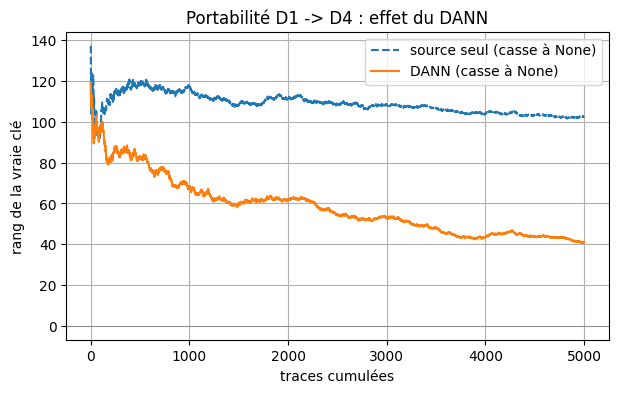

In [43]:
import matplotlib.pyplot as plt

ge_srconly = guessing_entropy(src_only.predict(Xa, batch_size=256, verbose=0),
                              atk['pt'], tk_tgt, n_attack=5000, n_exp=N_EXP)
ge_dann = guessing_entropy(dann.predict(Xa, batch_size=256, verbose=0)['class'],
                           atk['pt'], tk_tgt, n_attack=5000, n_exp=N_EXP)

n_so, n_dann = traces_to_break(ge_srconly), traces_to_break(ge_dann)
print(f'{SRC_DEV} -> {TGT_DEV}')
print('  source seul : casse à', n_so, '| meilleur rang atteint', round(float(ge_srconly.min()),1))
print('  DANN        : casse à', n_dann, '| meilleur rang atteint', round(float(ge_dann.min()),1))
print('  Diagnostic  : < 5 = presque cassé (plus d epoques) ; > 50 = n apprend pas (régler lambda/lr)')

RESULTS[TGT_DEV] = {'source_seul': n_so, 'dann': n_dann,
                    'min_srconly': float(ge_srconly.min()), 'min_dann': float(ge_dann.min())}

plt.figure(figsize=(7,4))
plt.plot(ge_srconly, '--', label=f'source seul (casse à {n_so})')
plt.plot(ge_dann, '-', label=f'DANN (casse à {n_dann})')
plt.axhline(0, color='gray', lw=0.5); plt.legend(); plt.grid(True)
plt.xlabel('traces cumulées'); plt.ylabel('rang de la vraie clé')
plt.title(f'Portabilité {SRC_DEV} -> {TGT_DEV} : effet du DANN')
plt.savefig(os.path.join(FIG_DIR, f'B_dann_{SRC_DEV}_{TGT_DEV}.pdf'), bbox_inches='tight')
plt.show()

## 8. Tableau récapitulatif
Relance les cellules 4 à 7 avec `TGT_DEV = 'D3'` puis `'D4'` ; le tableau se complète.

In [44]:
import pandas as pd
df = pd.DataFrame(RESULTS).T
df.index.name = 'Cible'
print('Traces pour casser (None = clé non récupérée) :')
df

Traces pour casser (None = clé non récupérée) :


,source_seul,dann,min_srconly,min_dann
Cible,,,,
D2,NaN,NaN,28.16,44.18
D3,NaN,NaN,52.70,61.82
D4,NaN,NaN,91.86,40.64


## 9. (Optionnel) Robustesse — moyenne sur plusieurs graines
À lancer quand le mode complet marche, pour obtenir des barres d'erreur dans le rapport.
Long : ré-entraîne le DANN une fois par graine.

In [54]:
def run_dann_once(seed):
    tf.keras.utils.set_random_seed(seed)
    # DANN
    m, g = build_dann(n_samples)
    s = LambdaSchedule(g, EPOCHS, warmup=WARMUP, max_lambda=MAX_LAMBDA)   # <- ton vrai lambda
    m.fit(X, {'class': y_class, 'domain': y_domain},
          sample_weight={'class': w_class, 'domain': w_domain},
          epochs=EPOCHS, batch_size=128, shuffle=True, verbose=0, callbacks=[s])
    ge_d = guessing_entropy(m.predict(Xa, batch_size=256, verbose=0)['class'],
                            atk['pt'], tk_tgt, n_attack=5000, n_exp=N_EXP)
    # transfert renormalisé (source-seul), même graine
    so = make_mlp(n_samples)
    so.fit(Xs, src['labels'], epochs=min(EPOCHS, 30), batch_size=128, verbose=0)
    ge_s = guessing_entropy(so.predict(Xa, batch_size=256, verbose=0),
                            atk['pt'], tk_tgt, n_attack=5000, n_exp=N_EXP)
    return ge_s.min(), ge_d.min()

SEEDS = [0, 1, 2]
res = np.array([run_dann_once(s) for s in SEEDS])   # colonnes : source-seul, DANN
print(f'{SRC_DEV} -> {TGT_DEV} sur {len(SEEDS)} graines (plancher de rang, plus bas = mieux) :')
print(f'  source-seul : {res[:,0].mean():.1f} ± {res[:,0].std():.1f}')
print(f'  DANN        : {res[:,1].mean():.1f} ± {res[:,1].std():.1f}')

D1 -> D2 sur 3 graines (plancher de rang, plus bas = mieux) :
  source-seul : 37.0 ± 18.3
  DANN        : 30.7 ± 10.3
